# Data Job Market Intelligence — Analysis

**Question:** For data roles, *which skills are in demand, what do they pay, and how do roles compare?*

This notebook reads the deduplicated warehouse built by the collection pipeline
(`src/collect.py`) and the skills extracted from posting text (`src/extract_skills.py`),
then walks through the findings. All tables come from `src/analysis.py` and all charts
from `src/figures.py`, so everything here is reproducible — re-run the pipeline and re-run
this notebook.

> **Honesty note:** salary figures use only *genuinely advertised* USD annual salaries.
> Adzuna-predicted salaries are flagged in the data and excluded — otherwise we'd be
> analyzing another model's estimates. Per-skill samples are still small; treat
> everything as directional and watch it firm up as the scheduled collector accumulates data.

In [1]:
%matplotlib inline
import os, sys
# Make the project importable whether this runs from repo root or notebooks/
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src import analysis, figures
from src.storage import load_warehouse, load_skills

jobs = load_warehouse()
skills = load_skills()
print(f'{len(jobs)} postings, {len(skills)} skill mentions')

439 postings, 1262 skill mentions


## 1. What's in the dataset

Three public APIs, deliberately complementary: Remotive + Jobicy contribute *real advertised*
salaries (but are remote-only); Adzuna adds volume, geography and on-site roles.

In [2]:
sal = analysis.build_salary_table(jobs)
print('By source        :', jobs['source'].value_counts().to_dict())
print('Remote / on-site :', int(jobs['remote'].sum()), '/', int((~jobs['remote']).sum()))
print('Advertised USD$  :', len(sal), 'postings with a clean annual salary')
jobs[['source', 'title', 'company', 'location', 'salary_min', 'salary_max', 'salary_is_predicted']].head()

By source        : {'adzuna': 150, 'jobicy': 116, 'jsearch': 79, 'remoteok': 68, 'remotive': 18, 'jooble': 8}
Remote / on-site : 206 / 233
Advertised USD$  : 81 postings with a clean annual salary


,source,title,company,location,salary_min,salary_max,salary_is_predicted
0,jobicy,Data Analyst,YipitData,USA,165000.0,205000.0,False
1,jobicy,Part-time Online Data Analyst – Dutch (NL),TELUS International,Netherlands,NaN,NaN,False
2,jobicy,Lead Business Analyst (Enterprise Modernisatio...,Thoughtworks,Singapore,NaN,NaN,False
3,jobicy,Business Systems Analyst,Natera,USA,NaN,NaN,False
4,jobicy,Research Scientist / Data Manager and Analyst,University of Colorado,USA,96000.0,101000.0,False


## 2. Which skills are most in demand?

Skills are extracted from description text with a curated taxonomy + a matcher that handles
ambiguous names (`R` vs "R&D", `Java` vs `JavaScript`). Demand = share of postings mentioning a skill.

In [3]:
analysis.demand_table(jobs, skills).head(15)

,skill,postings,pct_of_postings
0,Python,135,30.8
1,Machine Learning,114,26.0
2,SQL,109,24.8
3,Statistics,66,15.0
4,Tableau,48,10.9
5,Power BI,47,10.7
6,AWS,41,9.3
7,ETL,33,7.5
8,GCP,30,6.8
9,R,28,6.4


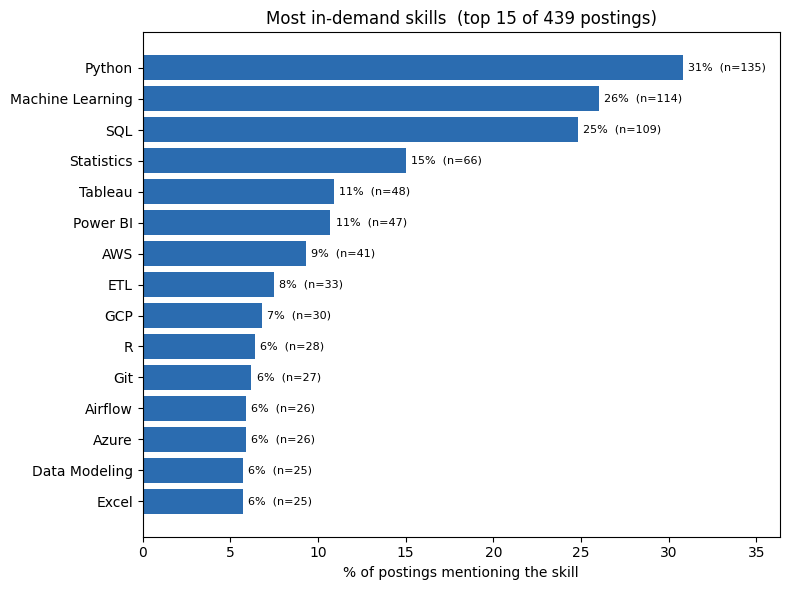

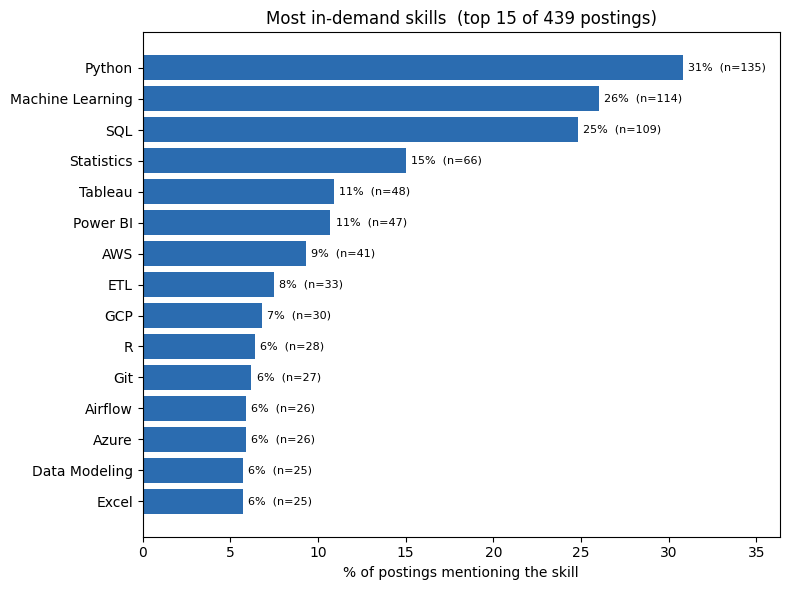

In [4]:
figures.build_demand(jobs, skills)

**Takeaway:** Python, SQL and Machine Learning dominate; everything else trails below ~10%.
SQL's strength is the clearest signal for an aspiring analyst — it shows up nearly everywhere.

## 3. What does each skill pay?

Median advertised salary among postings that mention each skill (USD/yr, advertised only,
skills with at least 5 such postings).

In [5]:
analysis.salary_by_skill(jobs, skills).head(15)

,skill,n,median_salary
0,Kubernetes,5,250000
1,Java,7,216250
2,Spark,5,185000
3,NLP,5,179000
4,JavaScript,6,178900
5,GCP,5,171650
6,Deep Learning,5,170200
7,Azure,5,170000
8,Hugging Face,6,167250
9,Databricks,5,165250


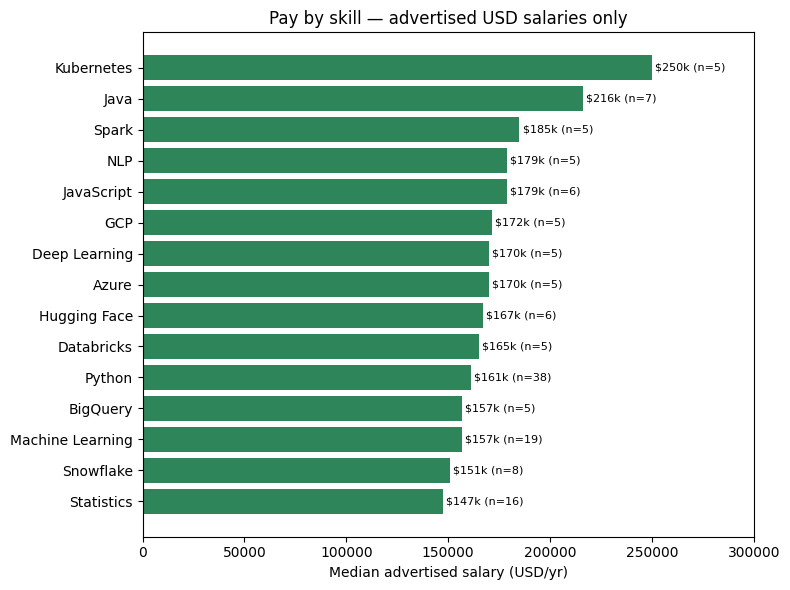

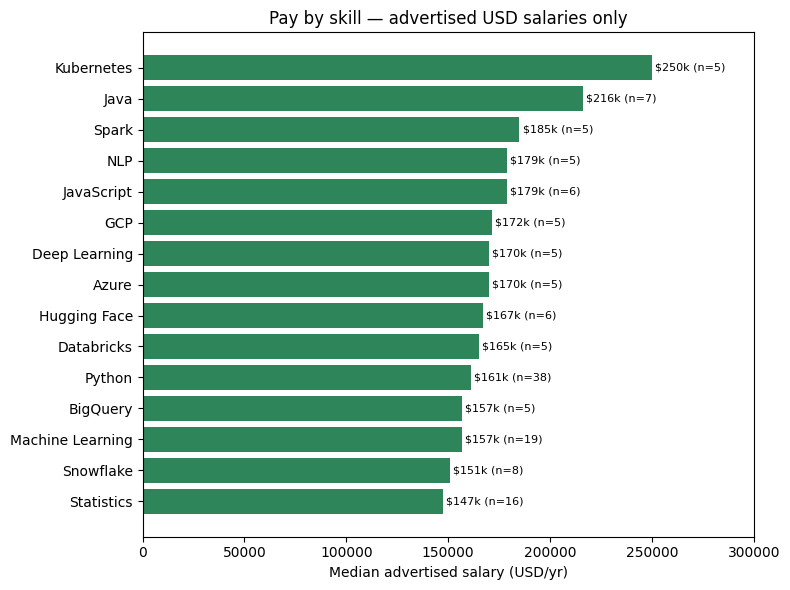

In [6]:
figures.build_salary_by_skill(jobs, skills)

**Takeaway:** specialized ML skills (Deep Learning, PyTorch, TensorFlow) cluster well above
general analytics tooling (dbt, Redshift, Airflow, R). The premium is real, though the small
per-skill samples mean exact dollar figures will move as more data lands.

## 4. How do roles compare?

Posting titles are bucketed into role families (Analyst / Scientist / Engineer / ML) and compared.

In [7]:
analysis.salary_by_role(jobs)

,role,n,median_salary
0,ML Engineer,12,165100
1,Data Engineer,8,163875
2,Data Scientist,8,142500
3,Other,33,128050
4,Data Analyst,20,115125


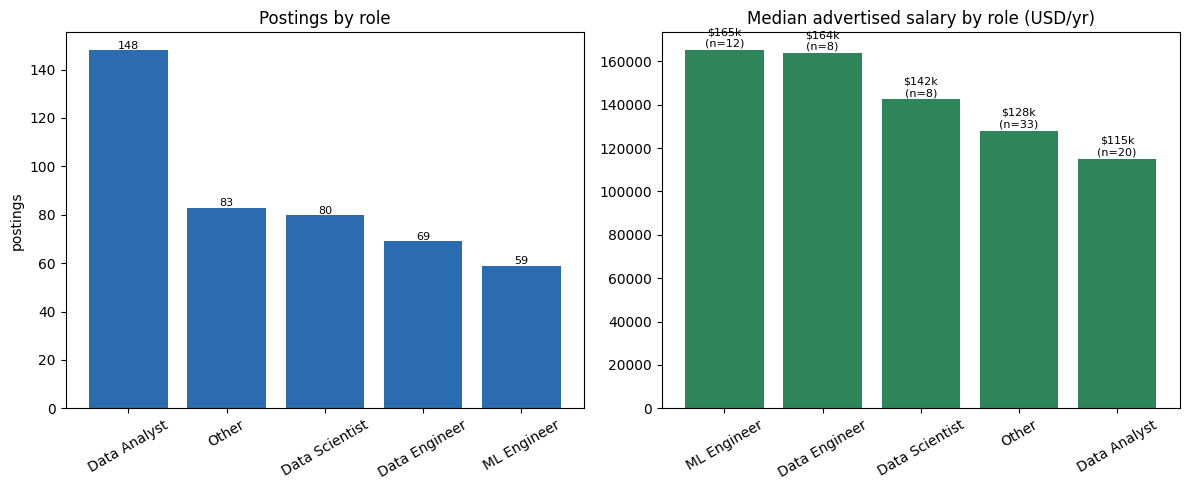

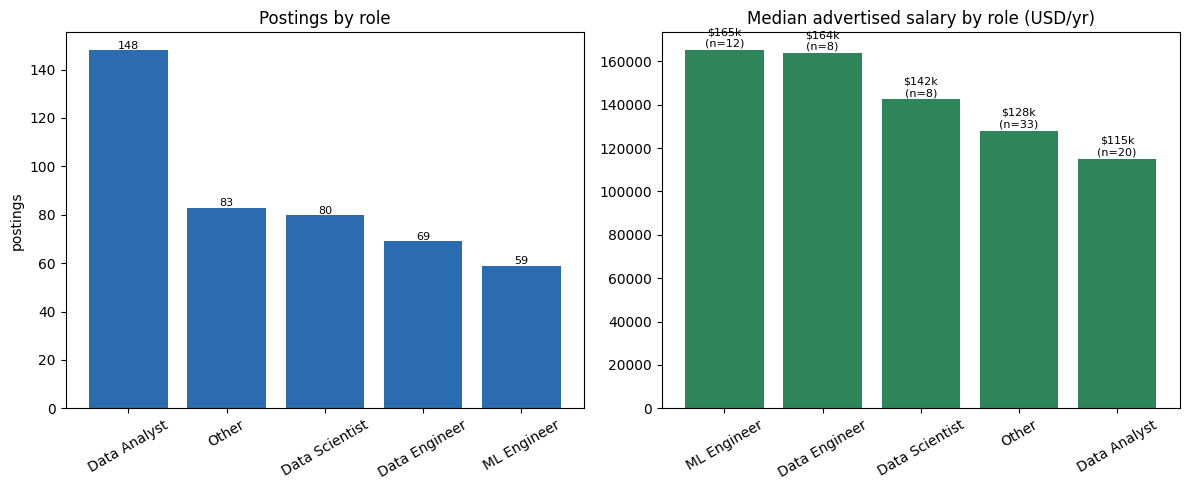

In [8]:
figures.build_roles(jobs)

**Takeaway:** ML Engineer > Data Scientist > Data Analyst on median advertised pay — the
ordering you'd expect, recovered straight from the data.

## 5. Which skills travel together?

Co-occurrence of the most common skills — how often two appear in the same posting.

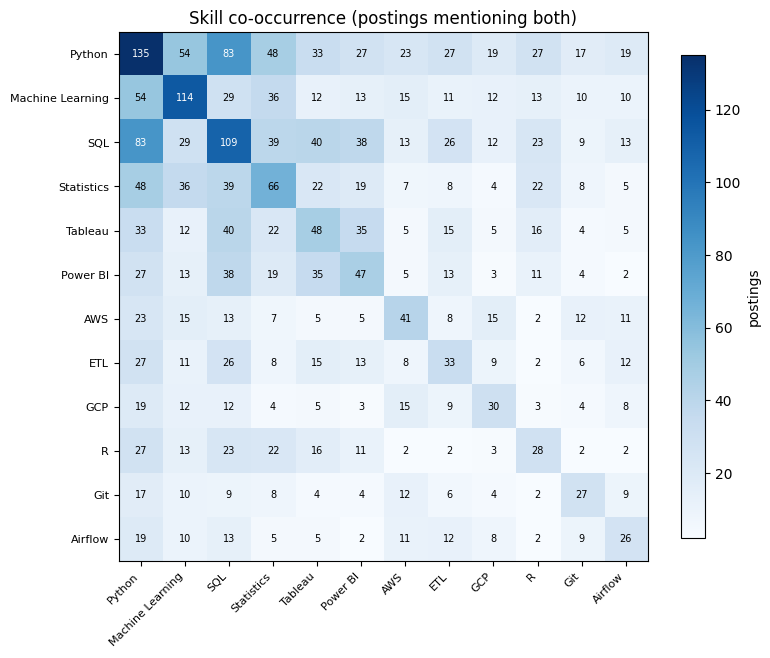

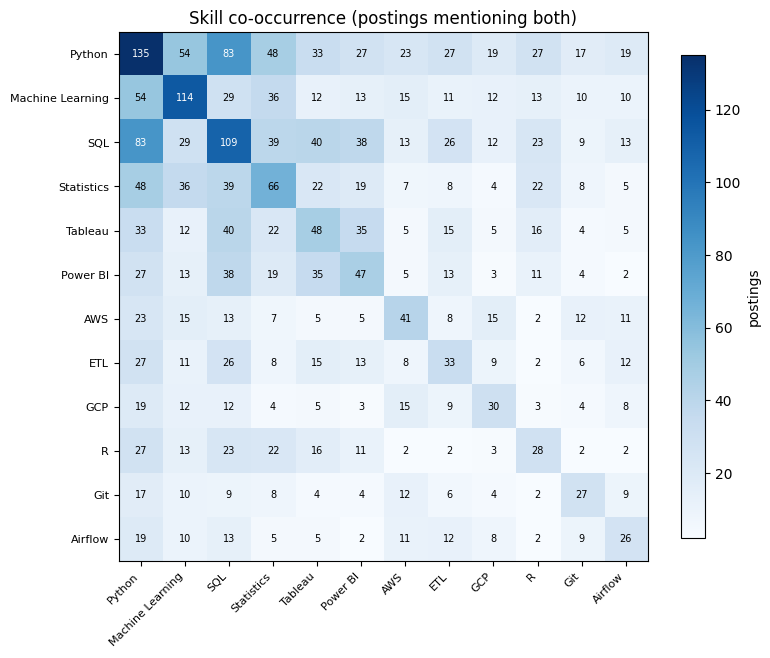

In [9]:
figures.build_cooccurrence(skills)

## 6. Demand by market — local vs. remote

The same skills are weighted very differently across markets — clearest in **Indonesia** (analyst/BI-heavy) vs. **remote-international** (Python/ML/cloud).

In [10]:
import pandas as pd

def market_share(market, n=8):
    ids = jobs.loc[jobs["market"] == market, "job_id"]
    s = skills[skills["job_id"].isin(ids)]
    total = max(1, s["job_id"].nunique())
    pct = (s["skill"].value_counts().head(n) / total * 100).round(0)
    return pct.astype(int).astype(str) + "%"

pd.DataFrame({
    "Indonesia": market_share("Indonesia"),
    "Remote (international)": market_share("Remote (international)"),
}).fillna("-")

,Indonesia,Remote (international)
skill,,
AWS,-,19%
ETL,35%,-
GCP,27%,12%
Git,-,17%
Machine Learning,38%,33%
Power BI,35%,-
Python,73%,57%
SQL,77%,37%
Statistics,42%,24%


**Takeaway:** Python+SQL is the backbone pairing of data work, while Excel sits almost on its
own — the signature of a non-programming, analyst-only tool.

---

## Caveats & what's next

- **Sampling bias:** remote-friendly, English-language postings; salary stats cover only the
  USD-advertised subset. Directional, not a census.
- **Dictionary recall:** a skill counts only if it's in the taxonomy, so demand %s are lower bounds.
- **Next (Phase 4):** predict advertised salary from skills/role/location, baseline-first, with
  honest error reporting. **Phase 5:** wrap these views in a deployed Streamlit dashboard.